In [2]:
# Policy Gradient RL for Stock Trading
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [3]:
# Load and normalize data
# df = pd.read_csv("apple_preprocessed_data.csv")
df = pd.read_csv("MSFT_2014-01-01_2024-01-01_processed.csv")
def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [3]:
# Environment class (same as DQN version)
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']
        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount
        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)
        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) >= 21:
            moving_avg = np.mean(list(self.history)[-21:])
            log_return = np.log(self.total_asset / (moving_avg + 1e-6))

        reward = log_return
        if action == 0:
            reward -= 0.001

        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

# Training with REINFORCE

def train_policy(df, episodes=30, gamma=0.99):
    state_dim = 9
    action_dim = 3
    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    reward_history = []
    asset_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()

        log_probs = []
        rewards = []

        while True:
            state_tensor = torch.tensor(state).float().unsqueeze(0)
            probs = policy(state_tensor)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            log_prob = dist.log_prob(action)
            next_state, reward, done = env.step(action.item())

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if done:
                break

        # Compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.stack([lp * ret for lp, ret in zip(log_probs, returns)]).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        reward_history.append(total_reward)
        asset_history.append(env.total_asset)
        print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Final Asset = ${env.total_asset:.2f}")

    return policy, reward_history, asset_history

In [7]:
# Run training
policy, rewards, assets = train_policy(df, episodes=100)

Episode 1: Reward = 3.73, Final Asset = $35590.60
Episode 2: Reward = 4.95, Final Asset = $41186.69
Episode 3: Reward = 2.98, Final Asset = $35121.91
Episode 4: Reward = 5.20, Final Asset = $45514.73
Episode 5: Reward = 6.08, Final Asset = $46340.60
Episode 6: Reward = 2.67, Final Asset = $31425.68
Episode 7: Reward = 2.62, Final Asset = $30927.03
Episode 8: Reward = 1.49, Final Asset = $28757.67
Episode 9: Reward = 2.72, Final Asset = $33389.07
Episode 10: Reward = 5.41, Final Asset = $43476.20
Episode 11: Reward = 0.56, Final Asset = $27460.32
Episode 12: Reward = 4.03, Final Asset = $35826.07
Episode 13: Reward = 6.58, Final Asset = $48236.35
Episode 14: Reward = 4.30, Final Asset = $37513.74
Episode 15: Reward = 2.24, Final Asset = $28838.28
Episode 16: Reward = 0.71, Final Asset = $25310.09
Episode 17: Reward = 3.44, Final Asset = $33435.64
Episode 18: Reward = 5.84, Final Asset = $43768.96
Episode 19: Reward = -2.28, Final Asset = $18967.86
Episode 20: Reward = 3.77, Final Asset 

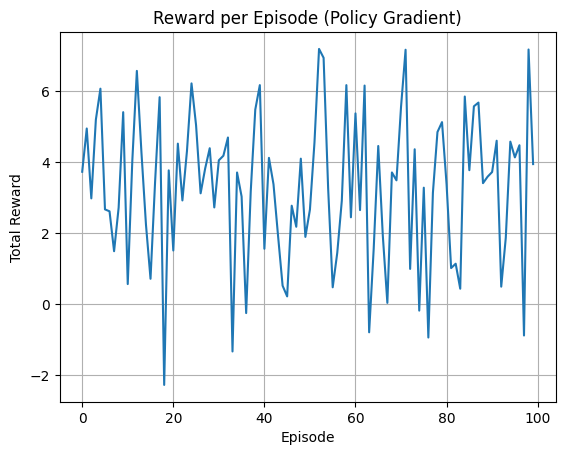

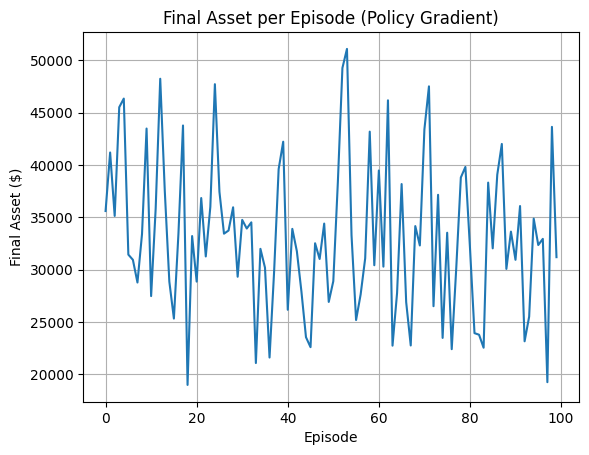

In [8]:
# Plotting
plt.plot(rewards)
plt.title("Reward per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()

# reward exposure

In [3]:
# Environment class (same as DQN version)
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    # improved 
    # def step(self, action):
    #     price = self.data.loc[self.day, 'Close']
    #     if action == 1:  # buy
    #         buy_amount = self.cash * 0.5
    #         shares = buy_amount / price
    #         self.stock += shares
    #         self.cash -= buy_amount
    #     elif action == 2:  # sell
    #         sell_shares = self.stock * 0.5
    #         self.cash += sell_shares * price
    #         self.stock -= sell_shares

    #     self.total_asset = self.cash + self.stock * price
    #     self.history.append(self.total_asset)
    #     self.day += 1
    #     done = self.day >= len(self.data) - 1

    #     log_return = 0
    #     if len(self.history) > 1:
    #         log_return = np.log(self.total_asset / self.history[-2])

    #     reward = log_return
    #     if action == 0:
    #         reward -= 0.001

    #     # Reduced risk penalty
    #     exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
    #     reward -= 0.001 * (exposure_ratio ** 2)

    #     next_state = self._get_state() if not done else np.zeros(9)
    #     return next_state, reward, done


    def step(self, action):
        price = self.data.loc[self.day, 'Close']
        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount
        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)
        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) > 1:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001

        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

# Training with REINFORCE

def train_policy(df, episodes=30, gamma=0.99):
    state_dim = 9
    action_dim = 3
    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    reward_history = []
    asset_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()

        log_probs = []
        rewards = []

        while True:
            state_tensor = torch.tensor(state).float().unsqueeze(0)
            probs = policy(state_tensor)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            log_prob = dist.log_prob(action)
            next_state, reward, done = env.step(action.item())

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if done:
                break

        # Compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.stack([lp * ret for lp, ret in zip(log_probs, returns)]).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        reward_history.append(total_reward)
        asset_history.append(env.total_asset)
        print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Final Asset = ${env.total_asset:.2f}")

    return policy, reward_history, asset_history

In [4]:
# Run training
policy, rewards, assets = train_policy(df, episodes=100)

Episode 1: Reward = -7.37, Final Asset = $34828.17
Episode 2: Reward = -7.83, Final Asset = $27153.55
Episode 3: Reward = -7.80, Final Asset = $24290.44
Episode 4: Reward = -6.66, Final Asset = $38421.09
Episode 5: Reward = -7.24, Final Asset = $48613.55
Episode 6: Reward = -7.16, Final Asset = $31704.50
Episode 7: Reward = -6.16, Final Asset = $32442.02
Episode 8: Reward = -7.05, Final Asset = $25074.69
Episode 9: Reward = -6.31, Final Asset = $30413.39
Episode 10: Reward = -5.92, Final Asset = $36150.39
Episode 11: Reward = -6.42, Final Asset = $28102.58
Episode 12: Reward = -5.69, Final Asset = $25261.87
Episode 13: Reward = -6.64, Final Asset = $18262.91
Episode 14: Reward = -5.78, Final Asset = $27090.12
Episode 15: Reward = -5.37, Final Asset = $30686.59
Episode 16: Reward = -5.41, Final Asset = $24841.98
Episode 17: Reward = -5.77, Final Asset = $28932.98
Episode 18: Reward = -5.25, Final Asset = $31137.91
Episode 19: Reward = -5.33, Final Asset = $32520.61
Episode 20: Reward = 

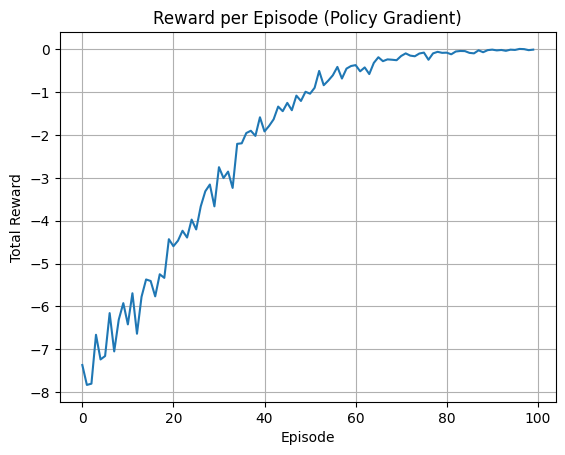

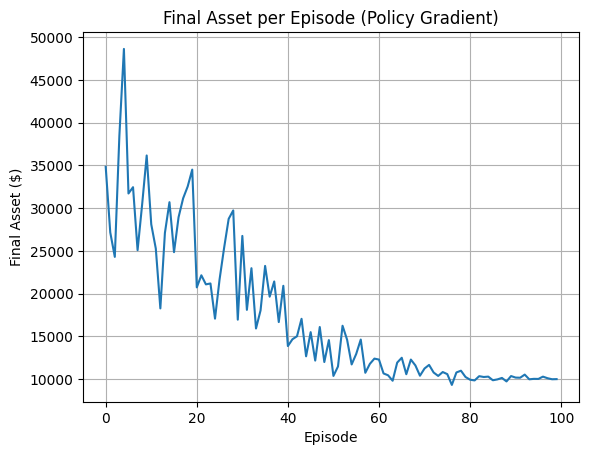

In [5]:
# Plotting
plt.plot(rewards)
plt.title("Reward per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()


# Redesign reward

In [4]:
# Environment class (same as DQN version)
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']
        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount
        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)
        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) > 1:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001

        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

# Training with REINFORCE

def train_policy(df, episodes=30, gamma=0.99):
    state_dim = 9
    action_dim = 3
    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    reward_history = []
    asset_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()

        log_probs = []
        rewards = []

        while True:
            state_tensor = torch.tensor(state).float().unsqueeze(0)
            probs = policy(state_tensor)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            log_prob = dist.log_prob(action)
            next_state, reward, done = env.step(action.item())

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if done:
                rewards[-1] += np.log(env.total_asset / env.initial_cash + 1e-6)
                break

        # Compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.stack([lp * ret for lp, ret in zip(log_probs, returns)]).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        reward_history.append(total_reward)
        asset_history.append(env.total_asset)
        print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Final Asset = ${env.total_asset:.2f}")

    return policy, reward_history, asset_history

In [8]:
# Run training
policy, rewards, assets = train_policy(df, episodes=100)

Episode 1: Reward = -6.67, Final Asset = $44523.67
Episode 2: Reward = -6.50, Final Asset = $39753.61
Episode 3: Reward = -6.99, Final Asset = $32363.57
Episode 4: Reward = -7.55, Final Asset = $29851.52
Episode 5: Reward = -7.18, Final Asset = $35696.81
Episode 6: Reward = -6.55, Final Asset = $29082.06
Episode 7: Reward = -6.58, Final Asset = $22940.58
Episode 8: Reward = -6.24, Final Asset = $37844.55
Episode 9: Reward = -6.15, Final Asset = $36273.71
Episode 10: Reward = -6.78, Final Asset = $30613.57
Episode 11: Reward = -5.51, Final Asset = $46223.61
Episode 12: Reward = -5.64, Final Asset = $37405.12
Episode 13: Reward = -6.06, Final Asset = $34471.31
Episode 14: Reward = -5.91, Final Asset = $32022.69
Episode 15: Reward = -4.67, Final Asset = $49299.44
Episode 16: Reward = -5.51, Final Asset = $28191.36
Episode 17: Reward = -5.48, Final Asset = $26825.82
Episode 18: Reward = -5.54, Final Asset = $33492.27
Episode 19: Reward = -5.66, Final Asset = $32304.09
Episode 20: Reward = 

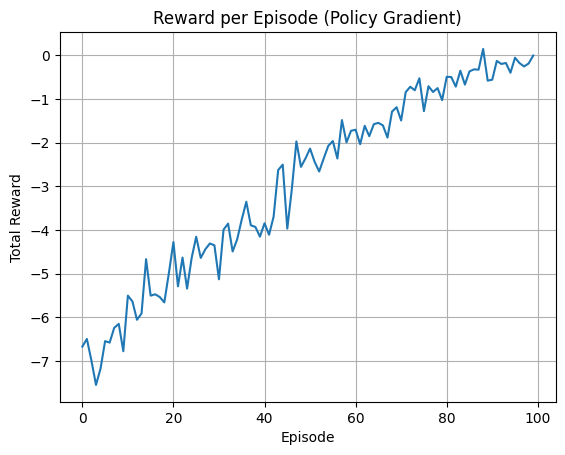

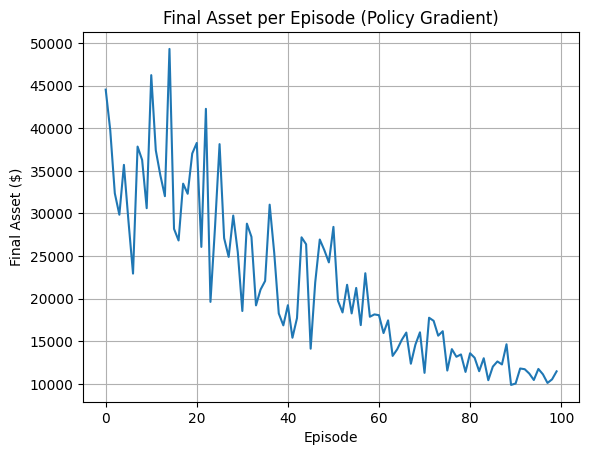

In [9]:
# Plotting
plt.plot(rewards)
plt.title("Reward per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Policy Gradient)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()


# Environment with imitation-based reward

In [22]:
# Load and preprocess data
# df = pd.read_csv("apple_preprocessed_data.csv")

# df = pd.read_csv("GOOGL_2014-01-01_2024-01-01_processed.csv")
df = pd.read_csv("MSFT_2014-01-01_2024-01-01_processed.csv")

def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [ ]:

class StockTradingEnv:
    def __init__(self, data, initial_cash=10000):
        self.data = data.copy()
        # Map ground truth actions: '-' → 0 (hold), 'v' → 1 (buy), '^' → 2 (sell)
        self.data['gt_action'] = self.data['ground_truth'].map({'-': 0, 'v': 1, '^': 2}).fillna(0).astype(int)
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist',
                    'Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        # Execute action
        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount
        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        # Update asset
        self.total_asset = self.cash + self.stock * price
        self.day += 1
        done = self.day >= len(self.data) - 1

        # Imitation reward: match agent action to ground truth
        gt_action = self.data.loc[self.day - 1, 'gt_action']
        if action == gt_action:
            reward = 1.0
        elif gt_action in [1, 2]:
            reward = -1.0
        else:
            reward = 0.0

        next_state = self._get_state() if not done else np.zeros(9)
        return next_state, reward, done

# Policy network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

# Training loop
def train_policy(df, episodes=30, gamma=0.99):
    state_dim = 9
    action_dim = 3
    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.001)

    reward_history = []
    asset_history = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()

        log_probs = []
        rewards = []

        while True:
            state_tensor = torch.tensor(state).float().unsqueeze(0)
            probs = policy(state_tensor)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            log_prob = dist.log_prob(action)
            next_state, reward, done = env.step(action.item())

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

            if done:
                break

        # Compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Loss and optimization
        loss = -torch.stack([lp * ret for lp, ret in zip(log_probs, returns)]).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        reward_history.append(total_reward)
        asset_history.append(env.total_asset)

        print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}, Final Asset = ${env.total_asset:.2f}")

    return policy, reward_history, asset_history


In [25]:
# Run training
policy, rewards, assets = train_policy(df, episodes=100)

Episode 1: Total Reward = -1.00, Final Asset = $17671.61
Episode 2: Total Reward = 0.00, Final Asset = $30659.12
Episode 3: Total Reward = -80.00, Final Asset = $36577.08
Episode 4: Total Reward = 36.00, Final Asset = $41556.47
Episode 5: Total Reward = -46.00, Final Asset = $38801.49
Episode 6: Total Reward = -28.00, Final Asset = $36167.68
Episode 7: Total Reward = -23.00, Final Asset = $33613.15
Episode 8: Total Reward = -3.00, Final Asset = $28383.90
Episode 9: Total Reward = -91.00, Final Asset = $40218.48
Episode 10: Total Reward = -9.00, Final Asset = $35251.30
Episode 11: Total Reward = 14.00, Final Asset = $25751.65
Episode 12: Total Reward = -21.00, Final Asset = $34396.57
Episode 13: Total Reward = 13.00, Final Asset = $22894.91
Episode 14: Total Reward = -15.00, Final Asset = $38628.45
Episode 15: Total Reward = 54.00, Final Asset = $20117.10
Episode 16: Total Reward = 14.00, Final Asset = $29303.66
Episode 17: Total Reward = 43.00, Final Asset = $26811.06
Episode 18: Total

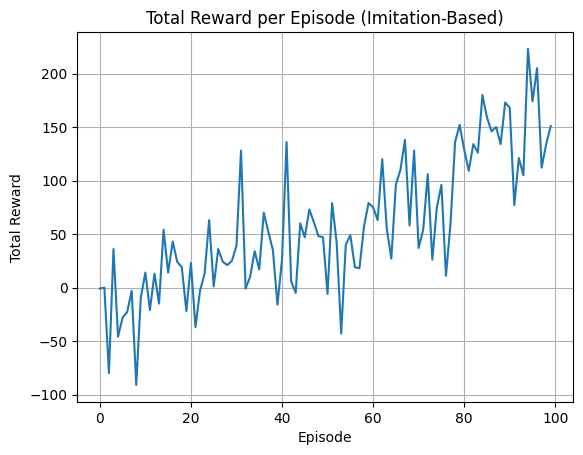

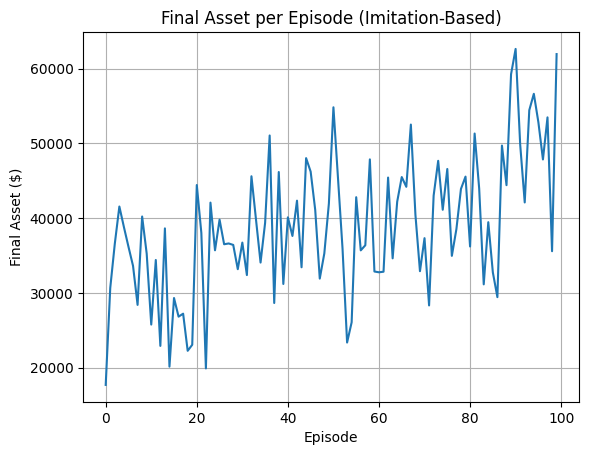

In [26]:
# Plot reward and asset history
plt.plot(rewards)
plt.title("Total Reward per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()

# ADD AUC

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from collections import deque
from sklearn.metrics import roc_auc_score
import copy

# Load and normalize data
df = pd.read_csv("apple_preprocessed_data.csv")

def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

# Define Environment
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        price = self.data.loc[self.day, 'Close']

        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount

        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        self.day += 1
        done = self.day >= len(self.data) - 1

        log_return = 0
        if len(self.history) >= 2:
            log_return = np.log(self.total_asset / self.history[-2])

        reward = log_return
        if action == 0:
            reward -= 0.001  # small penalty for holding

        # Add risk penalty for large exposure
        exposure_ratio = (self.stock * price) / (self.cash + self.stock * price + 1e-6)
        reward -= 0.01 * (exposure_ratio ** 2)

        next_state = self._get_state() if not done else np.zeros(len(self._get_state()))
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# AUC Helper
def compute_binary_auc(actions, ground_truth, mask):
    filtered_gt = [gt for gt, m in zip(ground_truth, mask) if m]
    filtered_pred = [a for a, m in zip(actions, mask) if m]
    bin_gt = [1 if x == 2 else 0 for x in filtered_gt]  # 2 = sell (1), 1 = buy (0)
    bin_pred = [1 if x == 2 else 0 for x in filtered_pred]
    try:
        return roc_auc_score(bin_gt, bin_pred)
    except:
        return None

# Training Function
def train_agent(df, episodes=30, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 5
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []
    auc_history = []
    final_assets = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        final_assets.append(env.total_asset)

        auc_val = compute_binary_auc(actions, ground_truth, eval_mask)
        auc_history.append(auc_val)

        print(f"Episode {episode+1}/{episodes} - Reward: {total_reward:.2f}, Asset: ${env.total_asset:.2f}, AUC: {auc_val if auc_val is not None else 'N/A'}")

    return agent, reward_history, auc_history, final_assets

In [43]:
# Train the agent
agent, rewards, aucs, assets = train_agent(df, episodes=100)

Episode 1/100 - Reward: -8.65, Asset: $18906.62, AUC: 0.4688866022376701
Episode 2/100 - Reward: -6.88, Asset: $47348.62, AUC: 0.5072731099560924
Episode 3/100 - Reward: -7.61, Asset: $33777.80, AUC: 0.4891614681080364
Episode 4/100 - Reward: -7.88, Asset: $27770.69, AUC: 0.5160176020174501
Episode 5/100 - Reward: -8.41, Asset: $37198.50, AUC: 0.5136468254200259
Episode 6/100 - Reward: -7.76, Asset: $29019.20, AUC: 0.47901770140882405
Episode 7/100 - Reward: -6.92, Asset: $35063.79, AUC: 0.5059858942202942
Episode 8/100 - Reward: -7.09, Asset: $30426.86, AUC: 0.5030129228274702
Episode 9/100 - Reward: -6.86, Asset: $39089.17, AUC: 0.476696620498399
Episode 10/100 - Reward: -7.54, Asset: $23849.33, AUC: 0.49049837953083375
Episode 11/100 - Reward: -7.14, Asset: $28787.17, AUC: 0.5066377847026932
Episode 12/100 - Reward: -7.04, Asset: $32857.32, AUC: 0.5058904005472372
Episode 13/100 - Reward: -7.10, Asset: $28807.40, AUC: 0.5021534797699577
Episode 14/100 - Reward: -7.23, Asset: $28402.

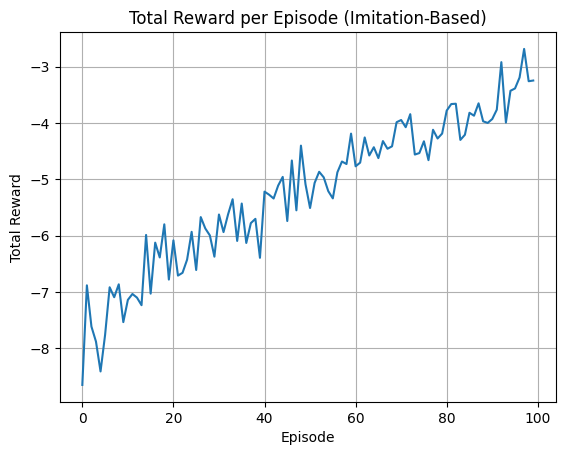

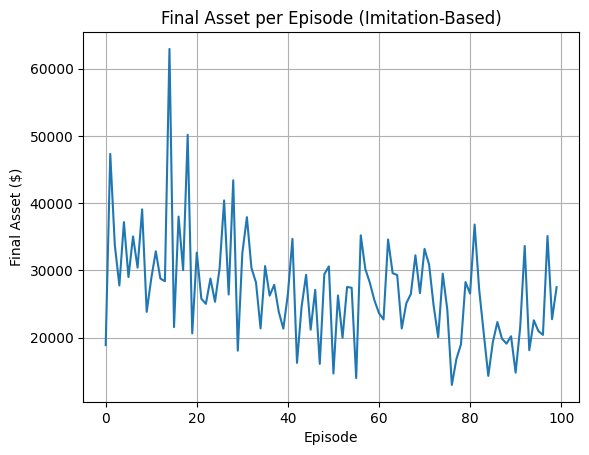

In [44]:
# Plot reward and asset history
plt.plot(rewards)
plt.title("Total Reward per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()

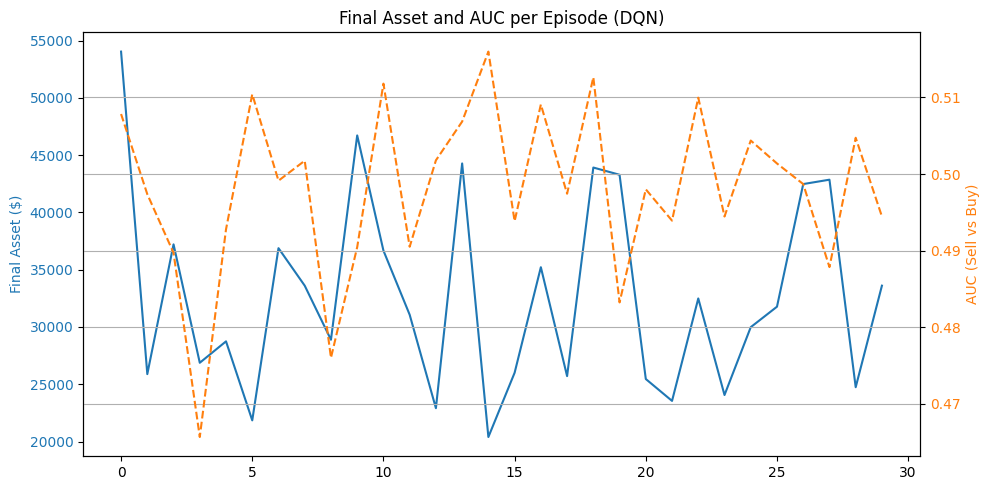

In [41]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(assets, color='tab:blue', label='Final Asset')
ax1.set_ylabel('Final Asset ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(aucs, color='tab:orange', linestyle='--', label='AUC')
ax2.set_ylabel('AUC (Sell vs Buy)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Final Asset and AUC per Episode (DQN)")
plt.xlabel("Episode")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
from scipy.stats import pearsonr

# Clean AUC list (remove None)
valid_data = [(a, auc) for a, auc in zip(assets, aucs) if auc is not None]
clean_assets, clean_aucs = zip(*valid_data)

# Compute Pearson correlation
corr, p_value = pearsonr(clean_assets, clean_aucs)
print(f"\nPearson Correlation between Final Asset and AUC: {corr:.4f}")
print(f"P-value: {p_value:.4f}")


Pearson Correlation between Final Asset and AUC: 0.0390
P-value: 0.8380


# DQN with imitated reward

In [46]:

# Load and normalize data
df = pd.read_csv("apple_preprocessed_data.csv")

def prepare_data(df):
    df = df.dropna()
    indicators = ['RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']
    df[indicators] = (df[indicators] - df[indicators].mean()) / df[indicators].std()
    df = df.reset_index(drop=True)
    return df

df = prepare_data(df)

In [47]:
# Define Environment with imitation-based reward
class StockTradingEnv:
    def __init__(self, data, initial_cash=10000, delay=21):
        self.data = data
        self.delay = delay
        self.initial_cash = initial_cash
        self.reset()

    def reset(self):
        self.day = 0
        self.cash = self.initial_cash
        self.stock = 0
        self.history = deque(maxlen=self.delay)
        self.total_asset = self.cash
        return self._get_state()

    def _get_state(self):
        features = ['Open_Growth', 'Close_Growth', 'High_Growth', 'Low_Growth', 'Volume_Growth']
        return self.data.loc[self.day, features].values.astype(np.float32)

    def step(self, action):
        label = self.data.loc[self.day, 'ground_truth'] if self.day < len(self.data) else '-'
        gt_action = 0
        if label == 'v':
            gt_action = 1
        elif label == '^':
            gt_action = 2

        price = self.data.loc[self.day, 'Close']
        if action == 1:  # buy
            buy_amount = self.cash * 0.5
            shares = buy_amount / price
            self.stock += shares
            self.cash -= buy_amount
        elif action == 2:  # sell
            sell_shares = self.stock * 0.5
            self.cash += sell_shares * price
            self.stock -= sell_shares

        self.total_asset = self.cash + self.stock * price
        self.history.append(self.total_asset)

        reward = 1.0 if action == gt_action and gt_action in [1, 2] else -1.0 if gt_action in [1, 2] else 0.0

        self.day += 1
        done = self.day >= len(self.data) - 1
        next_state = self._get_state() if not done else np.zeros(len(self._get_state()))
        return next_state, reward, done

# DQN Agent
class DQNAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.model(x)

# AUC Helper
def compute_binary_auc(actions, ground_truth, mask):
    filtered_gt = [gt for gt, m in zip(ground_truth, mask) if m]
    filtered_pred = [a for a, m in zip(actions, mask) if m]
    bin_gt = [1 if x == 2 else 0 for x in filtered_gt]
    bin_pred = [1 if x == 2 else 0 for x in filtered_pred]
    try:
        return roc_auc_score(bin_gt, bin_pred)
    except:
        return None

# Training Function
def train_agent(df, episodes=30, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                epsilon_min=0.1, batch_size=32, target_update_freq=5):
    state_dim = 5
    action_dim = 3
    agent = DQNAgent(state_dim, action_dim)
    target_agent = copy.deepcopy(agent)
    optimizer = optim.Adam(agent.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    memory = deque(maxlen=1000)

    reward_history = []
    auc_history = []
    final_assets = []

    for episode in range(episodes):
        env = StockTradingEnv(df)
        state = env.reset()
        total_reward = 0
        actions = []
        ground_truth = []
        eval_mask = []

        while True:
            if np.random.rand() < epsilon:
                action = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    q_values = agent(torch.tensor(state).float().unsqueeze(0))
                    action = torch.argmax(q_values).item()

            actions.append(action)
            label = df.loc[env.day, 'ground_truth'] if env.day < len(df) else '-'
            if label == '^':
                ground_truth.append(2)
                eval_mask.append(True)
            elif label == 'v':
                ground_truth.append(1)
                eval_mask.append(True)
            else:
                ground_truth.append(0)
                eval_mask.append(False)

            next_state, reward, done = env.step(action)
            memory.append((state, action, reward, next_state, done))
            total_reward += reward
            state = next_state

            if done:
                break

            if len(memory) >= batch_size:
                minibatch = random.sample(memory, batch_size)
                states, actions_b, rewards_b, next_states, dones = zip(*minibatch)

                states = torch.tensor(states).float()
                actions_b = torch.tensor(actions_b).long()
                rewards_b = torch.tensor(rewards_b).float()
                next_states = torch.tensor(next_states).float()
                dones = torch.tensor(dones).float()

                q_values = agent(states)
                next_q_values = target_agent(next_states)

                q_target = q_values.clone()
                for i in range(batch_size):
                    q_target[i, actions_b[i]] = rewards_b[i] + gamma * torch.max(next_q_values[i]) * (1 - dones[i])

                loss = loss_fn(q_values, q_target.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if episode % target_update_freq == 0:
            target_agent.load_state_dict(agent.state_dict())

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        reward_history.append(total_reward)
        final_assets.append(env.total_asset)

        auc_val = compute_binary_auc(actions, ground_truth, eval_mask)
        auc_history.append(auc_val)

        print(f"Episode {episode+1}/{episodes} - Reward: {total_reward:.2f}, Asset: ${env.total_asset:.2f}, AUC: {auc_val if auc_val is not None else 'N/A'}")

    return agent, reward_history, auc_history, final_assets

Episode 1/100 - Reward: -472.00, Asset: $27325.67, AUC: 0.4997992684015333
Episode 2/100 - Reward: -432.00, Asset: $27131.75, AUC: 0.49744505703310904
Episode 3/100 - Reward: -528.00, Asset: $34919.05, AUC: 0.5033909998187569
Episode 4/100 - Reward: -580.00, Asset: $30325.92, AUC: 0.46300302266707977
Episode 5/100 - Reward: -424.00, Asset: $43177.49, AUC: 0.5228064226316107
Episode 6/100 - Reward: -408.00, Asset: $32798.98, AUC: 0.5287065674312007
Episode 7/100 - Reward: -466.00, Asset: $64788.00, AUC: 0.49673080333565245
Episode 8/100 - Reward: -522.00, Asset: $52194.84, AUC: 0.4748033122662597
Episode 9/100 - Reward: -428.00, Asset: $36644.12, AUC: 0.5026767461213003
Episode 10/100 - Reward: -478.00, Asset: $23782.56, AUC: 0.4852169947556434
Episode 11/100 - Reward: -462.00, Asset: $28191.25, AUC: 0.5017383746197305
Episode 12/100 - Reward: -538.00, Asset: $37527.02, AUC: 0.466852002346416
Episode 13/100 - Reward: -436.00, Asset: $55933.16, AUC: 0.5118363433328851
Episode 14/100 - Re

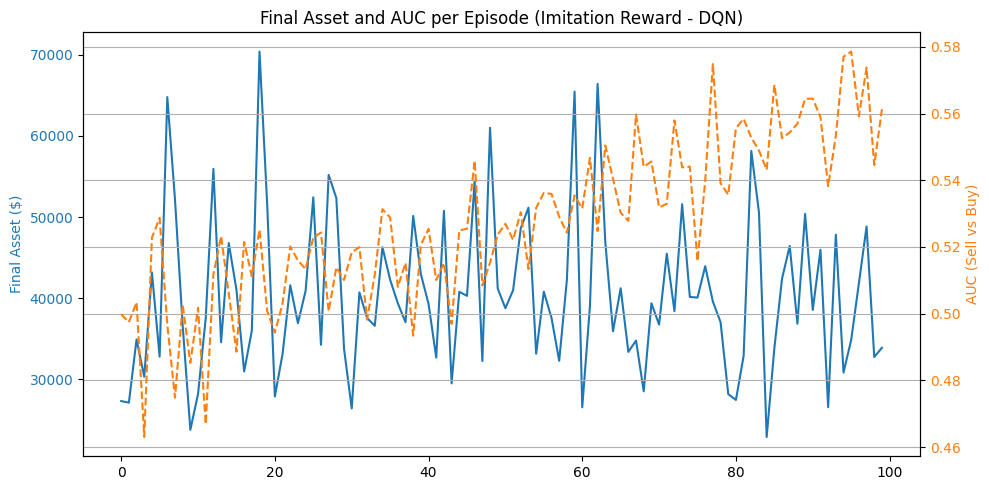

In [48]:
# Train and plot
agent, rewards, aucs, assets = train_agent(df, episodes=100)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(assets, color='tab:blue', label='Final Asset')
ax1.set_ylabel('Final Asset ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(aucs, color='tab:orange', linestyle='--', label='AUC')
ax2.set_ylabel('AUC (Sell vs Buy)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Final Asset and AUC per Episode (Imitation Reward - DQN)")
plt.xlabel("Episode")
plt.grid(True)
plt.tight_layout()
plt.show()

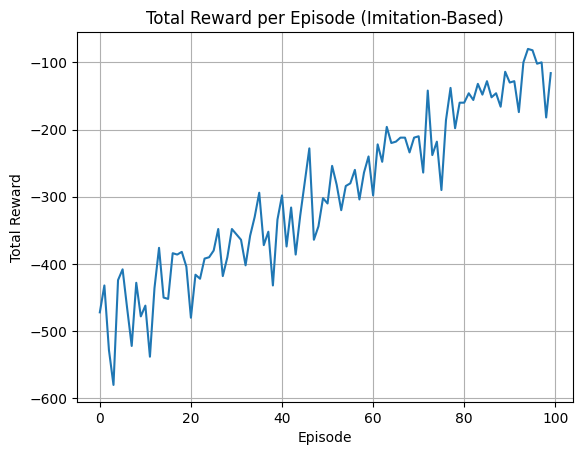

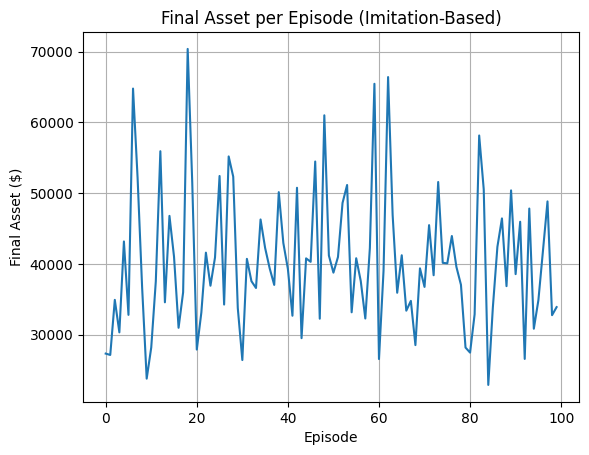

In [49]:
# Plot reward and asset history
plt.plot(rewards)
plt.title("Total Reward per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

plt.plot(assets)
plt.title("Final Asset per Episode (Imitation-Based)")
plt.xlabel("Episode")
plt.ylabel("Final Asset ($)")
plt.grid(True)
plt.show()